In [1]:
import os
import time
import psutil
import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

def get_current_ram_gb():
    """Lấy lượng RAM hiện tại tiến trình Python đang chiếm dụng (GB)"""
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 3)

def evaluate_models(file_path: str, n_splits: int = 5):
    print("=" * 85)
    print(f"📂 TEST DỮ LIỆU: {file_path}")
    print("=" * 85)

    if not os.path.exists(file_path):
        print(f"❌ Lỗi: Không tìm thấy file dữ liệu tại '{file_path}'")
        return

    df = pd.read_parquet(file_path) if file_path.endswith('.parquet') else pd.read_csv(file_path)

    n_rows, n_cols = df.shape
    dataset_ram_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

    target_col = 'TARGET'
    ignore_cols = ['SK_ID_CURR', target_col]
    X = df.drop(columns=[col for col in ignore_cols if col in df.columns])
    y = df[target_col]

    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].astype('category')

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    lgb_oof = np.zeros(len(X))
    xgb_oof = np.zeros(len(X))

    def calc_ks(y_true, y_pred):
        return ks_2samp(y_pred[y_true == 1], y_pred[y_true == 0]).statistic * 100

    # Danh sách lưu kết quả từng fold
    lgb_tr_aucs, lgb_va_aucs = [], []
    xgb_tr_aucs, xgb_va_aucs = [], []
    ens_tr_aucs, ens_va_aucs = [], []
    lgb_latencies, xgb_latencies = [], []

    lgb_params = {
        'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt',
        'learning_rate': 0.05, 'num_leaves': 31, 'random_state': 42,
        'n_jobs': -1, 'verbose': -1
    }
    xgb_params = {
        'objective': 'binary:logistic', 'eval_metric': 'auc', 'learning_rate': 0.05,
        'max_depth': 6, 'enable_categorical': True, 'tree_method': 'hist',
        'random_state': 42, 'n_jobs': -1
    }

    peak_ram_lgb = get_current_ram_gb()
    peak_ram_xgb = get_current_ram_gb()
    time_lgb_total = 0.0
    time_xgb_total = 0.0

    print(f"⚡ Đang chạy {n_splits}-Fold Cross Validation...")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        # --- 1. LightGBM ---
        t0_lgb = time.time()
        model_lgb = lgb.LGBMClassifier(**lgb_params, n_estimators=1000)
        model_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(50, verbose=False)])
        time_lgb_total += (time.time() - t0_lgb)
        peak_ram_lgb = max(peak_ram_lgb, get_current_ram_gb())

        lgb_tr_pred = model_lgb.predict_proba(X_tr)[:, 1]

        t0_inf = time.time()
        lgb_va_pred = model_lgb.predict_proba(X_va)[:, 1]
        lgb_latencies.append(((time.time() - t0_inf) / len(X_va)) * 1000)
        lgb_oof[val_idx] = lgb_va_pred

        # --- 2. XGBoost ---
        t0_xgb = time.time()
        model_xgb = xgb.XGBClassifier(**xgb_params, n_estimators=1000, early_stopping_rounds=50)
        model_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        time_xgb_total += (time.time() - t0_xgb)
        peak_ram_xgb = max(peak_ram_xgb, get_current_ram_gb())

        xgb_tr_pred = model_xgb.predict_proba(X_tr)[:, 1]

        t0_inf = time.time()
        xgb_va_pred = model_xgb.predict_proba(X_va)[:, 1]
        xgb_latencies.append(((time.time() - t0_inf) / len(X_va)) * 1000)
        xgb_oof[val_idx] = xgb_va_pred

        # --- 3. Ensemble Fold ---
        ens_tr_pred = 0.5 * lgb_tr_pred + 0.5 * xgb_tr_pred
        ens_va_pred = 0.5 * lgb_va_pred + 0.5 * xgb_va_pred

        # Lưu AUC từng fold
        lgb_tr_auc = roc_auc_score(y_tr, lgb_tr_pred)
        lgb_va_auc = roc_auc_score(y_va, lgb_va_pred)
        lgb_tr_aucs.append(lgb_tr_auc)
        lgb_va_aucs.append(lgb_va_auc)

        xgb_tr_auc = roc_auc_score(y_tr, xgb_tr_pred)
        xgb_va_auc = roc_auc_score(y_va, xgb_va_pred)
        xgb_tr_aucs.append(xgb_tr_auc)
        xgb_va_aucs.append(xgb_va_auc)

        ens_tr_auc = roc_auc_score(y_tr, ens_tr_pred)
        ens_va_auc = roc_auc_score(y_va, ens_va_pred)
        ens_tr_aucs.append(ens_tr_auc)
        ens_va_aucs.append(ens_va_auc)

        # Tính Gap từng fold
        gap_lgb_f = lgb_tr_auc - lgb_va_auc
        gap_xgb_f = xgb_tr_auc - xgb_va_auc
        gap_ens_f = ens_tr_auc - ens_va_auc

        # IN LOG CHI TIẾT TỪNG FOLD KÈM THEO GAP
        print(f"   ▫️ Fold {fold} | LGB Val: {lgb_va_auc:.5f} (Gap: {gap_lgb_f:+.5f}) | XGB Val: {xgb_va_auc:.5f} (Gap: {gap_xgb_f:+.5f}) | Ens Val: {ens_va_auc:.5f} (Gap: {gap_ens_f:+.5f})")

    # --- 🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG ---
    ensemble_oof = 0.5 * lgb_oof + 0.5 * xgb_oof
    lgb_auc = roc_auc_score(y, lgb_oof)
    xgb_auc = roc_auc_score(y, xgb_oof)
    ens_auc = roc_auc_score(y, ensemble_oof)

    print("\n" + "=" * 60)
    print("🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG")
    print("=" * 60)
    print(f"🔹 LightGBM : {lgb_auc:.5f}")
    print(f"🔹 XGBoost  : {xgb_auc:.5f}")
    print(f"🥇 Ensemble : {ens_auc:.5f}")
    print("=" * 60)

    # Tính mảng Gap
    lgb_gaps = np.array(lgb_tr_aucs) - np.array(lgb_va_aucs)
    xgb_gaps = np.array(xgb_tr_aucs) - np.array(xgb_va_aucs)
    ens_gaps = np.array(ens_tr_aucs) - np.array(ens_va_aucs)

    models_eval = [
        ('LightGBM', lgb_auc, lgb_tr_aucs, lgb_va_aucs, lgb_gaps, lgb_oof, time_lgb_total, peak_ram_lgb, np.mean(lgb_latencies)),
        ('XGBoost', xgb_auc, xgb_tr_aucs, xgb_va_aucs, xgb_gaps, xgb_oof, time_xgb_total, peak_ram_xgb, np.mean(xgb_latencies)),
        ('Ensemble (50/50)', ens_auc, ens_tr_aucs, ens_va_aucs, ens_gaps, ensemble_oof, time_lgb_total + time_xgb_total, max(peak_ram_lgb, peak_ram_xgb), np.mean(lgb_latencies) + np.mean(xgb_latencies))
    ]

    perf_records = []
    res_records = []

    for name, main_auc, tr_list, va_list, gaps, oof_preds, t_run, p_ram, lat in models_eval:
        mean_tr = np.mean(tr_list)
        mean_va = np.mean(va_list)

        perf_records.append({
            'Model': name,
            'ROC-AUC': f"{main_auc:.5f}",
            'Fold AUC (Mean ± Std)': f"{mean_va:.5f} ± {np.std(va_list):.5f}",
            'Train AUC': f"{mean_tr:.5f}",
            'Gap (Mean ± Std)': f"{np.mean(gaps):.5f} ± {np.std(gaps):.5f}",
            'Gini (%)': f"{(2 * main_auc - 1) * 100:.2f}%",
            'KS (%)': f"{calc_ks(y, oof_preds):.2f}%"
        })

        res_records.append({
            'Model': name,
            'Training Time': f"{t_run:.1f} s",
            'Peak RAM': f"{p_ram:.2f} GB",
            'Inference Latency': f"{lat:.4f} ms/sample"
        })

    # --- BẢNG 1: HIỆU NĂNG & CHỈ SỐ TÍN DỤNG ---
    print("\n📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)")
    display(pd.DataFrame(perf_records))

    # --- BẢNG 2: TIÊU HAO TÀI NGUYÊN & THÔNG SỐ DỮ LIỆU ---
    print("\n⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)")
    display(pd.DataFrame(res_records))

    # Đưa thông số cấu hình dữ liệu xuống ngay dưới Bảng 2
    print(f"📌 Thông số tập dữ liệu: {n_rows:,} dòng | {X.shape[1]} đặc trưng (cột) | Dung lượng trên RAM: {dataset_ram_mb:.1f} MB")

In [14]:
import os
import time
import json
import psutil
import joblib
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp
from scipy.optimize import minimize

warnings.filterwarnings('ignore')

def get_current_ram_gb():
    """Lấy lượng RAM hiện tại tiến trình Python đang chiếm dụng (GB)"""
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 3)

def calc_ks(y_true, y_pred):
    """Tính toán chỉ số Kolmogorov-Smirnov (KS)"""
    return ks_2samp(y_pred[y_true == 1], y_pred[y_true == 0]).statistic * 100

def evaluate_models_v2_optimized(
    file_path: str,
    n_splits: int = 5,
    save_models: bool = True,
    artifact_dir: str = "./saved_models_v2"
):
    print("=" * 85)
    print(f"📂 [V2 OPTIMIZED] ĐÁNH GIÁ MÔ HÌNH VỚI BEST HYPERPARAMETERS: {file_path}")
    print("=" * 85)

    if not os.path.exists(file_path):
        print(f"❌ Lỗi: Không tìm thấy file dữ liệu tại '{file_path}'")
        return

    if save_models:
        os.makedirs(artifact_dir, exist_ok=True)

    df = pd.read_parquet(file_path) if file_path.endswith('.parquet') else pd.read_csv(file_path)

    n_rows, n_cols = df.shape
    dataset_ram_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

    target_col = 'TARGET'
    ignore_cols = ['SK_ID_CURR', target_col]
    X = df.drop(columns=[col for col in ignore_cols if col in df.columns])
    y = df[target_col]

    # Chuẩn hóa biến Categorical cho GBDT
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].astype('category')

    # =========================================================================
    # 1. CẤU HÌNH THAM SỐ ĐÃ QUA TUNING (OPTUNA BEST TRIALS)
    # =========================================================================
    lgb_params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'learning_rate': 0.0218,
        'num_leaves': 54,
        'max_depth': 7,
        'min_child_samples': 87,
        'colsample_bytree': 0.6048,
        'subsample': 0.8906,
        'subsample_freq': 1,
        'reg_alpha': 5.7108,
        'reg_lambda': 0.0581,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    xgb_params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'enable_categorical': True,
        'learning_rate': 0.0245,
        'max_depth': 9,
        'min_child_weight': 160,
        'colsample_bytree': 0.8349,
        'subsample': 0.9237,
        'reg_alpha': 0.6219,
        'reg_lambda': 5.8294,
        'random_state': 42,
        'n_jobs': -1
    }

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    lgb_oof = np.zeros(len(X))
    xgb_oof = np.zeros(len(X))

    lgb_tr_aucs, lgb_va_aucs = [], []
    xgb_tr_aucs, xgb_va_aucs = [], []
    lgb_latencies, xgb_latencies = [], []

    trained_lgb_models = []
    trained_xgb_models = []

    peak_ram_lgb = get_current_ram_gb()
    peak_ram_xgb = get_current_ram_gb()
    time_lgb_total = 0.0
    time_xgb_total = 0.0

    print(f"⚡ Đang chạy {n_splits}-Fold Cross Validation (Phiên bản V2 Tối Ưu)...")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        # --- 2. Huấn luyện LightGBM ---
        t0_lgb = time.time()
        model_lgb = lgb.LGBMClassifier(**lgb_params, n_estimators=3000)
        model_lgb.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(stopping_rounds=60, verbose=False)]
        )
        time_lgb_total += (time.time() - t0_lgb)
        peak_ram_lgb = max(peak_ram_lgb, get_current_ram_gb())

        lgb_tr_pred = model_lgb.predict_proba(X_tr)[:, 1]

        t0_inf = time.time()
        lgb_va_pred = model_lgb.predict_proba(X_va)[:, 1]
        lgb_latencies.append(((time.time() - t0_inf) / len(X_va)) * 1000)
        lgb_oof[val_idx] = lgb_va_pred

        if save_models:
            joblib.dump(model_lgb, os.path.join(artifact_dir, f"lgb_model_fold_{fold}.joblib"))
        trained_lgb_models.append(model_lgb)

        # --- 3. Huấn luyện XGBoost ---
        t0_xgb = time.time()
        model_xgb = xgb.XGBClassifier(**xgb_params, n_estimators=3000, early_stopping_rounds=60)
        model_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        time_xgb_total += (time.time() - t0_xgb)
        peak_ram_xgb = max(peak_ram_xgb, get_current_ram_gb())

        xgb_tr_pred = model_xgb.predict_proba(X_tr)[:, 1]

        t0_inf = time.time()
        xgb_va_pred = model_xgb.predict_proba(X_va)[:, 1]
        xgb_latencies.append(((time.time() - t0_inf) / len(X_va)) * 1000)
        xgb_oof[val_idx] = xgb_va_pred

        if save_models:
            joblib.dump(model_xgb, os.path.join(artifact_dir, f"xgb_model_fold_{fold}.joblib"))
        trained_xgb_models.append(model_xgb)

        # --- 4. Ghi nhận metric từng Fold ---
        lgb_tr_auc = roc_auc_score(y_tr, lgb_tr_pred)
        lgb_va_auc = roc_auc_score(y_va, lgb_va_pred)
        lgb_tr_aucs.append(lgb_tr_auc)
        lgb_va_aucs.append(lgb_va_auc)

        xgb_tr_auc = roc_auc_score(y_tr, xgb_tr_pred)
        xgb_va_auc = roc_auc_score(y_va, xgb_va_pred)
        xgb_tr_aucs.append(xgb_tr_auc)
        xgb_va_aucs.append(xgb_va_auc)

        print(f"   ▫️ Fold {fold} | LGB Val: {lgb_va_auc:.5f} (Gap: {lgb_tr_auc - lgb_va_auc:+.5f}) | XGB Val: {xgb_va_auc:.5f} (Gap: {xgb_tr_auc - xgb_va_auc:+.5f})")

    # =========================================================================
    # 5. TỐI ƯU TRỌNG SỐ BLENDING DỰA TRÊN TOÀN BỘ OUT-OF-FOLD (OOF)
    # =========================================================================
    def loss_func(w):
        blend = w[0] * lgb_oof + (1 - w[0]) * xgb_oof
        return -roc_auc_score(y, blend)

    res = minimize(loss_func, [0.5], bounds=[(0.0, 1.0)], method='SLSQP')
    w_lgb = float(res.x[0])
    w_xgb = 1.0 - w_lgb

    opt_ensemble_oof = w_lgb * lgb_oof + w_xgb * xgb_oof

    ens_tr_aucs = []
    ens_va_aucs = []
    for f in range(n_splits):
        tr_pred_ens = w_lgb * lgb_tr_aucs[f] + w_xgb * xgb_tr_aucs[f]
        va_pred_ens = w_lgb * lgb_va_aucs[f] + w_xgb * xgb_va_aucs[f]
        ens_tr_aucs.append(tr_pred_ens)
        ens_va_aucs.append(va_pred_ens)

    lgb_auc = roc_auc_score(y, lgb_oof)
    xgb_auc = roc_auc_score(y, xgb_oof)
    opt_ens_auc = roc_auc_score(y, opt_ensemble_oof)

    print("\n" + "=" * 60)
    print("🏆 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC V2 (OOF ROC-AUC)")
    print("=" * 60)
    print(f"🔹 LightGBM (Tuned)    : {lgb_auc:.5f}")
    print(f"🔹 XGBoost (Tuned)     : {xgb_auc:.5f}")
    print(f"🥇 Optimal Blend       : {opt_ens_auc:.5f}")
    print(f"⚖️ Trọng số tối ưu     : LightGBM = {w_lgb*100:.1f}% | XGBoost = {w_xgb*100:.1f}%")
    print("=" * 60)

    # =========================================================================
    # 6. HIỂN THỊ BẢNG ĐỐI CHỨNG
    # =========================================================================
    lgb_gaps = np.array(lgb_tr_aucs) - np.array(lgb_va_aucs)
    xgb_gaps = np.array(xgb_tr_aucs) - np.array(xgb_va_aucs)
    ens_gaps = np.array(ens_tr_aucs) - np.array(ens_va_aucs)

    models_eval = [
        ('LightGBM (Tuned)', lgb_auc, lgb_tr_aucs, lgb_va_aucs, lgb_gaps, lgb_oof, time_lgb_total, peak_ram_lgb, np.mean(lgb_latencies)),
        ('XGBoost (Tuned)', xgb_auc, xgb_tr_aucs, xgb_va_aucs, xgb_gaps, xgb_oof, time_xgb_total, peak_ram_xgb, np.mean(xgb_latencies)),
        (f'Optimal Blend ({w_lgb:.2f}/{w_xgb:.2f})', opt_ens_auc, ens_tr_aucs, ens_va_aucs, ens_gaps, opt_ensemble_oof, time_lgb_total + time_xgb_total, max(peak_ram_lgb, peak_ram_xgb), np.mean(lgb_latencies) + np.mean(xgb_latencies))
    ]

    perf_records = []
    res_records = []

    for name, main_auc, tr_list, va_list, gaps, oof_preds, t_run, p_ram, lat in models_eval:
        perf_records.append({
            'Model': name,
            'ROC-AUC (OOF)': f"{main_auc:.5f}",
            'Fold AUC (Mean ± Std)': f"{np.mean(va_list):.5f} ± {np.std(va_list):.5f}",
            'Train AUC': f"{np.mean(tr_list):.5f}",
            'Overfit Gap': f"{np.mean(gaps):.5f} ± {np.std(gaps):.5f}",
            'Gini (%)': f"{(2 * main_auc - 1) * 100:.2f}%",
            'KS (%)': f"{calc_ks(y, oof_preds):.2f}%"
        })

        res_records.append({
            'Model': name,
            'Training Time': f"{t_run:.1f} s",
            'Peak RAM': f"{p_ram:.2f} GB",
            'Inference Latency': f"{lat:.4f} ms/sample"
        })

    print("\n📊 BẢNG 1: CHỈ SỐ RỦI RO TÍN DỤNG CHÍNH THỨC (V2 OPTIMIZED)")
    display(pd.DataFrame(perf_records))

    print("\n⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (V2 OPTIMIZED)")
    display(pd.DataFrame(res_records))

    print(f"\n📌 Thông số tập dữ liệu: {n_rows:,} dòng | {X.shape[1]} đặc trưng | RAM: {dataset_ram_mb:.1f} MB")

    # Lưu metadata để sử dụng cho bước inference tập Test
    blend_config = {
        'best_weight_lgb': w_lgb,
        'best_weight_xgb': w_xgb,
        'ensemble_auc': opt_ens_auc,
        'feature_names': list(X.columns)
    }
    with open(os.path.join(artifact_dir, "blend_config_v2.json"), "w") as f:
        json.dump(blend_config, f, indent=4)

    print(f"💾 Đã lưu cấu hình Ensemble & 10 Models vào: '{artifact_dir}'")

    return {
        'lgb_models': trained_lgb_models,
        'xgb_models': trained_xgb_models,
        'weights': (w_lgb, w_xgb),
        'oof_predictions': opt_ensemble_oof
    }

In [2]:

evaluate_models('../../data/processed/df_main_clean.parquet')

📂 TEST DỮ LIỆU: ../../data/processed/df_main_clean.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.75086 (Gap: +0.04189) | XGB Val: 0.75136 (Gap: +0.05840) | Ens Val: 0.75207 (Gap: +0.05138)
   ▫️ Fold 2 | LGB Val: 0.75817 (Gap: +0.06126) | XGB Val: 0.75776 (Gap: +0.05702) | Ens Val: 0.75914 (Gap: +0.06081)
   ▫️ Fold 3 | LGB Val: 0.74984 (Gap: +0.05388) | XGB Val: 0.74834 (Gap: +0.06122) | Ens Val: 0.75003 (Gap: +0.05889)
   ▫️ Fold 4 | LGB Val: 0.75786 (Gap: +0.06072) | XGB Val: 0.75666 (Gap: +0.05273) | Ens Val: 0.75831 (Gap: +0.05886)
   ▫️ Fold 5 | LGB Val: 0.74818 (Gap: +0.04943) | XGB Val: 0.74908 (Gap: +0.07144) | Ens Val: 0.74980 (Gap: +0.06219)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.75299
🔹 XGBoost  : 0.75261
🥇 Ensemble : 0.75387

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%)
0,LightGBM,0.75299,0.75298 ± 0.00420,0.80642,0.05344 ± 0.00726,50.60%,37.60%
1,XGBoost,0.75261,0.75264 ± 0.00388,0.81280,0.06016 ± 0.00627,50.52%,37.49%
2,Ensemble (50/50),0.75387,0.75387 ± 0.00405,0.81230,0.05842 ± 0.00374,50.77%,37.66%



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,13.1 s,0.86 GB,0.0022 ms/sample
1,XGBoost,27.6 s,0.86 GB,0.0010 ms/sample
2,Ensemble (50/50),40.7 s,0.86 GB,0.0032 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 21 đặc trưng (cột) | Dung lượng trên RAM: 74.2 MB


In [3]:
evaluate_models('/Users/nguyenminhtri/FinalYearPro/data/processed/table/df_main_clean_fe.parquet')

📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/table/df_main_clean_fe.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.76027 (Gap: +0.06312) | XGB Val: 0.75934 (Gap: +0.07816) | Ens Val: 0.76130 (Gap: +0.07265)
   ▫️ Fold 2 | LGB Val: 0.76880 (Gap: +0.07203) | XGB Val: 0.76862 (Gap: +0.05838) | Ens Val: 0.77005 (Gap: +0.06816)
   ▫️ Fold 3 | LGB Val: 0.75849 (Gap: +0.08690) | XGB Val: 0.75703 (Gap: +0.05882) | Ens Val: 0.75909 (Gap: +0.07691)
   ▫️ Fold 4 | LGB Val: 0.76504 (Gap: +0.04958) | XGB Val: 0.76484 (Gap: +0.06961) | Ens Val: 0.76643 (Gap: +0.06139)
   ▫️ Fold 5 | LGB Val: 0.75850 (Gap: +0.07088) | XGB Val: 0.75971 (Gap: +0.07389) | Ens Val: 0.76035 (Gap: +0.07416)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.76220
🔹 XGBoost  : 0.76189
🥇 Ensemble : 0.76343

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%)
0,LightGBM,0.76220,0.76222 ± 0.00407,0.83072,0.06850 ± 0.01219,52.44%,38.96%
1,XGBoost,0.76189,0.76191 ± 0.00422,0.82968,0.06777 ± 0.00796,52.38%,38.77%
2,Ensemble (50/50),0.76343,0.76344 ± 0.00414,0.83410,0.07065 ± 0.00543,52.69%,39.10%



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,18.9 s,1.59 GB,0.0021 ms/sample
1,XGBoost,40.7 s,1.59 GB,0.0009 ms/sample
2,Ensemble (50/50),59.5 s,1.59 GB,0.0030 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 45 đặc trưng (cột) | Dung lượng trên RAM: 130.6 MB


In [4]:
evaluate_models('/Users/nguyenminhtri/FinalYearPro/data/processed/df_main_x_bureau.parquet')

📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/df_main_x_bureau.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.77150 (Gap: +0.06585) | XGB Val: 0.77116 (Gap: +0.08967) | Ens Val: 0.77284 (Gap: +0.07998)
   ▫️ Fold 2 | LGB Val: 0.77909 (Gap: +0.08931) | XGB Val: 0.77812 (Gap: +0.08923) | Ens Val: 0.78042 (Gap: +0.09167)
   ▫️ Fold 3 | LGB Val: 0.76926 (Gap: +0.06685) | XGB Val: 0.77018 (Gap: +0.08626) | Ens Val: 0.77109 (Gap: +0.07894)
   ▫️ Fold 4 | LGB Val: 0.77857 (Gap: +0.06454) | XGB Val: 0.77800 (Gap: +0.08769) | Ens Val: 0.77991 (Gap: +0.07858)
   ▫️ Fold 5 | LGB Val: 0.76974 (Gap: +0.10369) | XGB Val: 0.76988 (Gap: +0.10670) | Ens Val: 0.77152 (Gap: +0.10758)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.77357
🔹 XGBoost  : 0.77344
🥇 Ensemble : 0.77512

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%)
0,LightGBM,0.77357,0.77363 ± 0.00431,0.85168,0.07805 ± 0.01576,54.71%,40.54%
1,XGBoost,0.77344,0.77347 ± 0.00377,0.86538,0.09191 ± 0.00749,54.69%,40.85%
2,Ensemble (50/50),0.77512,0.77516 ± 0.00413,0.86250,0.08735 ± 0.01122,55.02%,40.93%



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,66.0 s,4.16 GB,0.0030 ms/sample
1,XGBoost,301.7 s,2.55 GB,0.0016 ms/sample
2,Ensemble (50/50),367.6 s,4.16 GB,0.0046 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 417 đặc trưng (cột) | Dung lượng trên RAM: 1003.3 MB


In [5]:
evaluate_models('/Users/nguyenminhtri/FinalYearPro/data/processed/df_main_x_bureau_all.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/df_main_x_bureau_all.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.77141 (Gap: +0.09766) | XGB Val: 0.77074 (Gap: +0.10490) | Ens Val: 0.77284 (Gap: +0.10363)
   ▫️ Fold 2 | LGB Val: 0.77825 (Gap: +0.07558) | XGB Val: 0.77821 (Gap: +0.07265) | Ens Val: 0.77967 (Gap: +0.07611)
   ▫️ Fold 3 | LGB Val: 0.76995 (Gap: +0.08172) | XGB Val: 0.77009 (Gap: +0.10733) | Ens Val: 0.77161 (Gap: +0.09723)
   ▫️ Fold 4 | LGB Val: 0.77798 (Gap: +0.06123) | XGB Val: 0.77784 (Gap: +0.10608) | Ens Val: 0.77988 (Gap: +0.08833)
   ▫️ Fold 5 | LGB Val: 0.76909 (Gap: +0.09449) | XGB Val: 0.77109 (Gap: +0.11267) | Ens Val: 0.77181 (Gap: +0.10616)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.77327
🔹 XGBoost  : 0.77353
🥇 Ensemble : 0.77511

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%)
0,LightGBM,0.77327,0.77333 ± 0.00397,0.85547,0.08214 ± 0.01322,54.65%,40.66%
1,XGBoost,0.77353,0.77359 ± 0.00363,0.87432,0.10073 ± 0.01429,54.71%,40.79%
2,Ensemble (50/50),0.77511,0.77516 ± 0.00379,0.86946,0.09429 ± 0.01098,55.02%,40.91%



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,69.2 s,4.32 GB,0.0033 ms/sample
1,XGBoost,412.7 s,3.73 GB,0.0018 ms/sample
2,Ensemble (50/50),481.9 s,4.32 GB,0.0050 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 496 đặc trưng (cột) | Dung lượng trên RAM: 1188.7 MB


In [6]:
evaluate_models('/Users/nguyenminhtri/FinalYearPro/data/processed/df_main_x_bureau_x_prev.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/df_main_x_bureau_x_prev.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.77992 (Gap: +0.09975) | XGB Val: 0.78060 (Gap: +0.10159) | Ens Val: 0.78190 (Gap: +0.10288)
   ▫️ Fold 2 | LGB Val: 0.78834 (Gap: +0.06191) | XGB Val: 0.79119 (Gap: +0.12300) | Ens Val: 0.79231 (Gap: +0.09986)
   ▫️ Fold 3 | LGB Val: 0.77804 (Gap: +0.10723) | XGB Val: 0.77710 (Gap: +0.10272) | Ens Val: 0.77906 (Gap: +0.10762)
   ▫️ Fold 4 | LGB Val: 0.78827 (Gap: +0.09608) | XGB Val: 0.78706 (Gap: +0.11679) | Ens Val: 0.78973 (Gap: +0.10881)
   ▫️ Fold 5 | LGB Val: 0.77868 (Gap: +0.12441) | XGB Val: 0.78006 (Gap: +0.13245) | Ens Val: 0.78136 (Gap: +0.13073)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78254
🔹 XGBoost  : 0.78319
🥇 Ensemble : 0.78483

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%)
0,LightGBM,0.78254,0.78265 ± 0.00466,0.88053,0.09788 ± 0.02045,56.51%,42.42%
1,XGBoost,0.78319,0.78320 ± 0.00515,0.89852,0.11531 ± 0.01185,56.64%,42.61%
2,Ensemble (50/50),0.78483,0.78487 ± 0.00518,0.89485,0.10998 ± 0.01086,56.97%,42.75%



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,175.3 s,3.58 GB,0.0052 ms/sample
1,XGBoost,984.4 s,3.58 GB,0.0029 ms/sample
2,Ensemble (50/50),1159.7 s,3.58 GB,0.0082 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 1089 đặc trưng (cột) | Dung lượng trên RAM: 2579.9 MB


In [7]:
evaluate_models('/Users/nguyenminhtri/FinalYearPro/data/processed/df_main_x_bureau_x_prev_x_pos.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/df_main_x_bureau_x_prev_x_pos.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.78166 (Gap: +0.09964) | XGB Val: 0.78298 (Gap: +0.12299) | Ens Val: 0.78431 (Gap: +0.11407)
   ▫️ Fold 2 | LGB Val: 0.79185 (Gap: +0.07776) | XGB Val: 0.79323 (Gap: +0.12060) | Ens Val: 0.79480 (Gap: +0.10380)
   ▫️ Fold 3 | LGB Val: 0.77904 (Gap: +0.08453) | XGB Val: 0.77885 (Gap: +0.11183) | Ens Val: 0.78058 (Gap: +0.10105)
   ▫️ Fold 4 | LGB Val: 0.78906 (Gap: +0.07643) | XGB Val: 0.78884 (Gap: +0.11222) | Ens Val: 0.79086 (Gap: +0.09811)
   ▫️ Fold 5 | LGB Val: 0.78034 (Gap: +0.10381) | XGB Val: 0.78123 (Gap: +0.11095) | Ens Val: 0.78249 (Gap: +0.10978)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78435
🔹 XGBoost  : 0.78503
🥇 Ensemble : 0.78659

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%)
0,LightGBM,0.78435,0.78439 ± 0.00510,0.87283,0.08843 ± 0.01127,56.87%,42.89%
1,XGBoost,0.78503,0.78503 ± 0.00526,0.90074,0.11572 ± 0.00504,57.01%,43.02%
2,Ensemble (50/50),0.78659,0.78661 ± 0.00536,0.89197,0.10536 ± 0.00581,57.32%,43.38%



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,173.8 s,3.33 GB,0.0053 ms/sample
1,XGBoost,1059.7 s,3.33 GB,0.0034 ms/sample
2,Ensemble (50/50),1233.5 s,3.33 GB,0.0087 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 1183 đặc trưng (cột) | Dung lượng trên RAM: 2800.4 MB


In [8]:
evaluate_models('/Users/nguyenminhtri/FinalYearPro/data/processed/df_main_x_bureau_x_prev_x_pos_x_ins.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/df_main_x_bureau_x_prev_x_pos_x_ins.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.78461 (Gap: +0.07052) | XGB Val: 0.78571 (Gap: +0.10722) | Ens Val: 0.78681 (Gap: +0.09263)
   ▫️ Fold 2 | LGB Val: 0.79413 (Gap: +0.08710) | XGB Val: 0.79646 (Gap: +0.10872) | Ens Val: 0.79728 (Gap: +0.10054)
   ▫️ Fold 3 | LGB Val: 0.78342 (Gap: +0.09326) | XGB Val: 0.78305 (Gap: +0.10515) | Ens Val: 0.78484 (Gap: +0.10138)
   ▫️ Fold 4 | LGB Val: 0.79197 (Gap: +0.09416) | XGB Val: 0.79170 (Gap: +0.10674) | Ens Val: 0.79366 (Gap: +0.10262)
   ▫️ Fold 5 | LGB Val: 0.78379 (Gap: +0.09011) | XGB Val: 0.78533 (Gap: +0.13431) | Ens Val: 0.78660 (Gap: +0.11726)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78757
🔹 XGBoost  : 0.78840
🥇 Ensemble : 0.78982

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%)
0,LightGBM,0.78757,0.78758 ± 0.00453,0.87461,0.08703 ± 0.00862,57.51%,43.52%
1,XGBoost,0.78840,0.78845 ± 0.00492,0.90088,0.11243 ± 0.01100,57.68%,43.49%
2,Ensemble (50/50),0.78982,0.78984 ± 0.00479,0.89272,0.10289 ± 0.00799,57.96%,43.88%



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,203.2 s,3.09 GB,0.0057 ms/sample
1,XGBoost,1144.1 s,3.09 GB,0.0041 ms/sample
2,Ensemble (50/50),1347.3 s,3.09 GB,0.0097 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 1235 đặc trưng (cột) | Dung lượng trên RAM: 2922.4 MB


In [9]:
evaluate_models('/Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.78688 (Gap: +0.08014) | XGB Val: 0.78698 (Gap: +0.12059) | Ens Val: 0.78886 (Gap: +0.10444)
   ▫️ Fold 2 | LGB Val: 0.79478 (Gap: +0.08588) | XGB Val: 0.79680 (Gap: +0.09783) | Ens Val: 0.79747 (Gap: +0.09405)
   ▫️ Fold 3 | LGB Val: 0.78524 (Gap: +0.09914) | XGB Val: 0.78446 (Gap: +0.12967) | Ens Val: 0.78692 (Gap: +0.11742)
   ▫️ Fold 4 | LGB Val: 0.79306 (Gap: +0.09567) | XGB Val: 0.79290 (Gap: +0.10296) | Ens Val: 0.79471 (Gap: +0.10133)
   ▫️ Fold 5 | LGB Val: 0.78477 (Gap: +0.07325) | XGB Val: 0.78623 (Gap: +0.12419) | Ens Val: 0.78739 (Gap: +0.10448)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78894
🔹 XGBoost  : 0.78941
🥇 Ensemble : 0.79104

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%)
0,LightGBM,0.78894,0.78895 ± 0.00416,0.87576,0.08682 ± 0.00959,57.79%,43.60%
1,XGBoost,0.78941,0.78947 ± 0.00463,0.90452,0.11505 ± 0.01241,57.88%,43.79%
2,Ensemble (50/50),0.79104,0.79107 ± 0.00424,0.89541,0.10434 ± 0.00756,58.21%,44.08%



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,249.6 s,3.16 GB,0.0062 ms/sample
1,XGBoost,1276.8 s,2.94 GB,0.0044 ms/sample
2,Ensemble (50/50),1526.4 s,3.16 GB,0.0106 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 1378 đặc trưng (cột) | Dung lượng trên RAM: 3257.9 MB


In [10]:
evaluate_models('/Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v2.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v2.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.78660 (Gap: +0.08124) | XGB Val: 0.78670 (Gap: +0.10148) | Ens Val: 0.78823 (Gap: +0.09370)
   ▫️ Fold 2 | LGB Val: 0.79437 (Gap: +0.05635) | XGB Val: 0.79579 (Gap: +0.10104) | Ens Val: 0.79698 (Gap: +0.08314)
   ▫️ Fold 3 | LGB Val: 0.78453 (Gap: +0.08044) | XGB Val: 0.78440 (Gap: +0.09921) | Ens Val: 0.78599 (Gap: +0.09179)
   ▫️ Fold 4 | LGB Val: 0.79302 (Gap: +0.07033) | XGB Val: 0.79269 (Gap: +0.10172) | Ens Val: 0.79453 (Gap: +0.08923)
   ▫️ Fold 5 | LGB Val: 0.78447 (Gap: +0.10338) | XGB Val: 0.78647 (Gap: +0.11582) | Ens Val: 0.78727 (Gap: +0.11166)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78851
🔹 XGBoost  : 0.78919
🥇 Ensemble : 0.79055

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%)
0,LightGBM,0.78851,0.78860 ± 0.00425,0.86695,0.07835 ± 0.01541,57.70%,43.57%
1,XGBoost,0.78919,0.78921 ± 0.00430,0.89307,0.10386 ± 0.00605,57.84%,43.78%
2,Ensemble (50/50),0.79055,0.79060 ± 0.00434,0.88451,0.09391 ± 0.00957,58.11%,43.94%



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,190.8 s,3.28 GB,0.0046 ms/sample
1,XGBoost,818.3 s,3.28 GB,0.0021 ms/sample
2,Ensemble (50/50),1009.1 s,3.28 GB,0.0068 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 1030 đặc trưng (cột) | Dung lượng trên RAM: 2441.5 MB


In [11]:
evaluate_models('/Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v3.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v3.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.78692 (Gap: +0.08143) | XGB Val: 0.78642 (Gap: +0.11344) | Ens Val: 0.78834 (Gap: +0.10060)
   ▫️ Fold 2 | LGB Val: 0.79481 (Gap: +0.07182) | XGB Val: 0.79589 (Gap: +0.10109) | Ens Val: 0.79727 (Gap: +0.08931)
   ▫️ Fold 3 | LGB Val: 0.78448 (Gap: +0.07388) | XGB Val: 0.78483 (Gap: +0.09900) | Ens Val: 0.78618 (Gap: +0.08872)
   ▫️ Fold 4 | LGB Val: 0.79317 (Gap: +0.08905) | XGB Val: 0.79260 (Gap: +0.10500) | Ens Val: 0.79462 (Gap: +0.09936)
   ▫️ Fold 5 | LGB Val: 0.78387 (Gap: +0.11052) | XGB Val: 0.78640 (Gap: +0.12023) | Ens Val: 0.78695 (Gap: +0.11746)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78859
🔹 XGBoost  : 0.78920
🥇 Ensemble : 0.79064

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%)
0,LightGBM,0.78859,0.78865 ± 0.00451,0.87399,0.08534 ± 0.01398,57.72%,43.48%
1,XGBoost,0.78920,0.78923 ± 0.00426,0.89698,0.10775 ± 0.00796,57.84%,43.63%
2,Ensemble (50/50),0.79064,0.79067 ± 0.00444,0.88976,0.09909 ± 0.01042,58.13%,43.95%



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,192.3 s,3.97 GB,0.0045 ms/sample
1,XGBoost,712.9 s,3.97 GB,0.0025 ms/sample
2,Ensemble (50/50),905.2 s,3.97 GB,0.0070 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 876 đặc trưng (cột) | Dung lượng trên RAM: 2080.2 MB


In [12]:
evaluate_models('/Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.78646 (Gap: +0.08209) | XGB Val: 0.78661 (Gap: +0.10634) | Ens Val: 0.78816 (Gap: +0.09674)
   ▫️ Fold 2 | LGB Val: 0.79533 (Gap: +0.09974) | XGB Val: 0.79551 (Gap: +0.10499) | Ens Val: 0.79741 (Gap: +0.10440)
   ▫️ Fold 3 | LGB Val: 0.78534 (Gap: +0.11796) | XGB Val: 0.78466 (Gap: +0.11334) | Ens Val: 0.78680 (Gap: +0.11802)
   ▫️ Fold 4 | LGB Val: 0.79298 (Gap: +0.06058) | XGB Val: 0.79212 (Gap: +0.11120) | Ens Val: 0.79445 (Gap: +0.09110)
   ▫️ Fold 5 | LGB Val: 0.78436 (Gap: +0.09100) | XGB Val: 0.78556 (Gap: +0.11849) | Ens Val: 0.78661 (Gap: +0.10772)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78883
🔹 XGBoost  : 0.78887
🥇 Ensemble : 0.79065

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%)
0,LightGBM,0.78883,0.78889 ± 0.00441,0.87917,0.09028 ± 0.01900,57.77%,43.66%
1,XGBoost,0.78887,0.78889 ± 0.00420,0.89976,0.11087 ± 0.00489,57.77%,43.70%
2,Ensemble (50/50),0.79065,0.79069 ± 0.00442,0.89428,0.10360 ± 0.00926,58.13%,43.97%



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,189.6 s,3.38 GB,0.0050 ms/sample
1,XGBoost,903.9 s,3.25 GB,0.0028 ms/sample
2,Ensemble (50/50),1093.6 s,3.38 GB,0.0077 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 1041 đặc trưng (cột) | Dung lượng trên RAM: 2467.3 MB


In [13]:
evaluate_models('/Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4_clean.parquet')


📂 TEST DỮ LIỆU: /Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4_clean.parquet
⚡ Đang chạy 5-Fold Cross Validation...
   ▫️ Fold 1 | LGB Val: 0.78629 (Gap: +0.11133) | XGB Val: 0.78714 (Gap: +0.11966) | Ens Val: 0.78867 (Gap: +0.11752)
   ▫️ Fold 2 | LGB Val: 0.79512 (Gap: +0.07813) | XGB Val: 0.79655 (Gap: +0.10376) | Ens Val: 0.79778 (Gap: +0.09361)
   ▫️ Fold 3 | LGB Val: 0.78512 (Gap: +0.10137) | XGB Val: 0.78409 (Gap: +0.09336) | Ens Val: 0.78606 (Gap: +0.09988)
   ▫️ Fold 4 | LGB Val: 0.79362 (Gap: +0.08290) | XGB Val: 0.79271 (Gap: +0.10761) | Ens Val: 0.79506 (Gap: +0.09773)
   ▫️ Fold 5 | LGB Val: 0.78395 (Gap: +0.08934) | XGB Val: 0.78492 (Gap: +0.10686) | Ens Val: 0.78588 (Gap: +0.10047)

🏆 BẢNG KẾT QUẢ ROC-AUC TRUYỀN THỐNG
🔹 LightGBM : 0.78876
🔹 XGBoost  : 0.78908
🥇 Ensemble : 0.79067

📊 BẢNG 1: CHỈ SỐ ĐÁNH GIÁ (METRICS)


,Model,ROC-AUC,Fold AUC (Mean ± Std),Train AUC,Gap (Mean ± Std),Gini (%),KS (%)
0,LightGBM,0.78876,0.78882 ± 0.00462,0.88143,0.09261 ± 0.01218,57.75%,43.76%
1,XGBoost,0.78908,0.78908 ± 0.00480,0.89533,0.10625 ± 0.00842,57.82%,43.80%
2,Ensemble (50/50),0.79067,0.79069 ± 0.00486,0.89253,0.10184 ± 0.00820,58.13%,44.05%



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (COMPUTATIONAL COST)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM,181.9 s,3.31 GB,0.0045 ms/sample
1,XGBoost,724.5 s,3.31 GB,0.0024 ms/sample
2,Ensemble (50/50),906.4 s,3.31 GB,0.0069 ms/sample


📌 Thông số tập dữ liệu: 307,511 dòng | 902 đặc trưng (cột) | Dung lượng trên RAM: 2141.2 MB


In [15]:
evaluate_models_v2_optimized('/Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4_clean.parquet')

📂 [V2 OPTIMIZED] ĐÁNH GIÁ MÔ HÌNH VỚI BEST HYPERPARAMETERS: /Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4_clean.parquet
⚡ Đang chạy 5-Fold Cross Validation (Phiên bản V2 Tối Ưu)...
   ▫️ Fold 1 | LGB Val: 0.79093 (Gap: +0.11907) | XGB Val: 0.79124 (Gap: +0.08070)
   ▫️ Fold 2 | LGB Val: 0.80078 (Gap: +0.09704) | XGB Val: 0.79978 (Gap: +0.06387)
   ▫️ Fold 3 | LGB Val: 0.78869 (Gap: +0.10376) | XGB Val: 0.78880 (Gap: +0.08553)
   ▫️ Fold 4 | LGB Val: 0.79712 (Gap: +0.10263) | XGB Val: 0.79715 (Gap: +0.07182)
   ▫️ Fold 5 | LGB Val: 0.79003 (Gap: +0.10964) | XGB Val: 0.78944 (Gap: +0.08621)

🏆 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC V2 (OOF ROC-AUC)
🔹 LightGBM (Tuned)    : 0.79348
🔹 XGBoost (Tuned)     : 0.79324
🥇 Optimal Blend       : 0.79439
⚖️ Trọng số tối ưu     : LightGBM = 50.0% | XGBoost = 50.0%

📊 BẢNG 1: CHỈ SỐ RỦI RO TÍN DỤNG CHÍNH THỨC (V2 OPTIMIZED)


,Model,ROC-AUC (OOF),Fold AUC (Mean ± Std),Train AUC,Overfit Gap,Gini (%),KS (%)
0,LightGBM (Tuned),0.79348,0.79351 ± 0.00464,0.89994,0.10643 ± 0.00748,58.70%,44.46%
1,XGBoost (Tuned),0.79324,0.79328 ± 0.00439,0.87091,0.07762 ± 0.00859,58.65%,44.44%
2,Optimal Blend (0.50/0.50),0.79439,0.79340 ± 0.00451,0.88542,0.09203 ± 0.00722,58.88%,44.59%



⚙️ BẢNG 2: TIÊU HAO TÀI NGUYÊN (V2 OPTIMIZED)


,Model,Training Time,Peak RAM,Inference Latency
0,LightGBM (Tuned),590.1 s,2.88 GB,0.0131 ms/sample
1,XGBoost (Tuned),1634.8 s,2.88 GB,0.0062 ms/sample
2,Optimal Blend (0.50/0.50),2224.9 s,2.88 GB,0.0193 ms/sample



📌 Thông số tập dữ liệu: 307,511 dòng | 902 đặc trưng | RAM: 2141.2 MB
💾 Đã lưu cấu hình Ensemble & 10 Models vào: './saved_models_v2'


{'lgb_models': [LGBMClassifier(colsample_bytree=0.6048, learning_rate=0.0218, max_depth=7,
                 metric='auc', min_child_samples=87, n_estimators=3000, n_jobs=-1,
                 num_leaves=54, objective='binary', random_state=42,
                 reg_alpha=5.7108, reg_lambda=0.0581, subsample=0.8906,
                 subsample_freq=1, verbose=-1),
  LGBMClassifier(colsample_bytree=0.6048, learning_rate=0.0218, max_depth=7,
                 metric='auc', min_child_samples=87, n_estimators=3000, n_jobs=-1,
                 num_leaves=54, objective='binary', random_state=42,
                 reg_alpha=5.7108, reg_lambda=0.0581, subsample=0.8906,
                 subsample_freq=1, verbose=-1),
  LGBMClassifier(colsample_bytree=0.6048, learning_rate=0.0218, max_depth=7,
                 metric='auc', min_child_samples=87, n_estimators=3000, n_jobs=-1,
                 num_leaves=54, objective='binary', random_state=42,
                 reg_alpha=5.7108, reg_lambda=0.0581, subsa

📂 Đang tải dữ liệu: /Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4_clean.parquet
📊 Dữ liệu gốc: 307,511 dòng | 902 đặc trưng
🎲 Trích xuất mẫu phân tầng 10,000 dòng (giữ nguyên tỷ lệ nợ xấu)...
✅ Mẫu trích xuất thành công: 9,999 dòng
   Tỷ lệ nợ xấu (TARGET=1) trong mẫu: 8.07%

🚀 [1/3] Đang huấn luyện mô hình Champion trên 100% dữ liệu (~1-2 phút)...
✅ Huấn luyện xong trong 119.2 giây!

⚡ [2/3] Đang tính TreeSHAP trên 10,000 hồ sơ (~1 - 1.5 phút)...
🎉 Hoàn thành tính TreeSHAP sau: 10.4 giây!

📊 [3/3] Đang vẽ và lưu biểu đồ Beeswarm chất lượng cao...


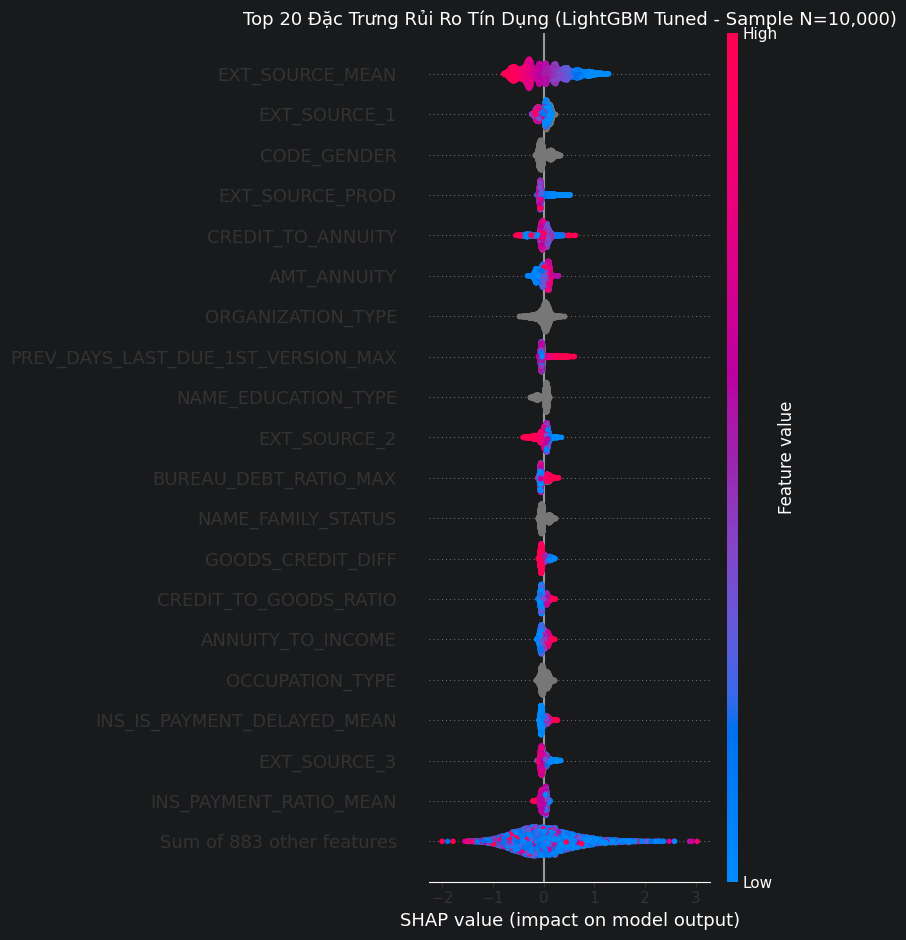

💾 Đã lưu ảnh báo cáo sắc nét tại: shap_reports/shap_beeswarm_10k.png


In [20]:
import os
import time
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. ĐỌC DỮ LIỆU
file_path = '/Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4_clean.parquet'
print(f"📂 Đang tải dữ liệu: {file_path}")
df = pd.read_parquet(file_path)

target_col = 'TARGET'
ignore_cols = ['SK_ID_CURR', target_col]
X = df.drop(columns=[c for c in ignore_cols if c in df.columns])
y = df[target_col]

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype('category')

print(f"📊 Dữ liệu gốc: {X.shape[0]:,} dòng | {X.shape[1]} đặc trưng")

# 2. TRÍCH XUẤT MẪU ĐẠI DIỆN PHÂN TẦNG 10,000 HỒ SƠ
N_SAMPLE = 10000
print(f"🎲 Trích xuất mẫu phân tầng {N_SAMPLE:,} dòng (giữ nguyên tỷ lệ nợ xấu)...")
X_sample = X.groupby(y, group_keys=False).apply(
    lambda s: s.sample(int(N_SAMPLE * len(s) / len(X)), random_state=42)
)
y_sample = y.loc[X_sample.index]

print(f"✅ Mẫu trích xuất thành công: {X_sample.shape[0]:,} dòng")
print(f"   Tỷ lệ nợ xấu (TARGET=1) trong mẫu: {y_sample.mean() * 100:.2f}%")

# 3. HUẤN LUYỆN MÔ HÌNH CHAMPION TRÊN TOÀN BỘ DỮ LIỆU
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.021825282433423233,
    'num_leaves': 54,
    'max_depth': 7,
    'min_child_samples': 87,
    'colsample_bytree': 0.6047822116703159,
    'subsample': 0.8906002785722761,
    'subsample_freq': 1,
    'reg_alpha': 5.710785677539034,
    'reg_lambda': 0.0581442340641234,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

print("\n🚀 [1/3] Đang huấn luyện mô hình Champion trên 100% dữ liệu (~1-2 phút)...")
t0 = time.time()
model = lgb.LGBMClassifier(**lgb_params, n_estimators=1000)
model.fit(X, y)
print(f"✅ Huấn luyện xong trong {time.time() - t0:.1f} giây!")

# 4. TÍNH TOÁN TREESHAP TRÊN 10,000 MẪU
print(f"\n⚡ [2/3] Đang tính TreeSHAP trên {N_SAMPLE:,} hồ sơ (~1 - 1.5 phút)...")
t_shap = time.time()
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)
print(f"🎉 Hoàn thành tính TreeSHAP sau: {time.time() - t_shap:.1f} giây!")

# 5. XUẤT BIỂU ĐỒ VÀ LƯU ẢNH BÁO CÁO (300 DPI)
print("\n📊 [3/3] Đang vẽ và lưu biểu đồ Beeswarm chất lượng cao...")
os.makedirs('shap_reports', exist_ok=True)

plt.figure(figsize=(11, 8.5))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title(f"Top 20 Đặc Trưng Rủi Ro Tín Dụng (LightGBM Tuned - Sample N={N_SAMPLE:,})", fontsize=13)
plt.tight_layout()

output_img = 'shap_reports/shap_beeswarm_10k.png'
plt.savefig(output_img, dpi=300)
plt.show()

print(f"💾 Đã lưu ảnh báo cáo sắc nét tại: {output_img}")

📂 Đang tải dữ liệu: /Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4_clean.parquet
🚀 Đang huấn luyện mô hình Champion trên 100% dữ liệu (~1-2 phút)...
⚡ Khởi tạo TreeSHAP Explainer...

📋 PHIẾU ĐÁNH GIÁ VÀ GIẢI TRÌNH TÍN DỤNG | HỒ SƠ: 100002
🎯 Xác suất nợ xấu dự báo: 28.60% (Ngưỡng an toàn: 15.0%)
⚖️ ĐỀ XUẤT TỰ ĐỘNG: ❌ TỪ CHỐI CHO VAY (DECLINE)
----------------------------------------------------------------------
📌 TOP 5 YẾU TỐ QUYẾT ĐỊNH (REASON CODES CHO THẨM ĐỊNH VIÊN):
  1. [⚠️ Tăng rủi ro (Điểm trừ)] EXT_SOURCE_MEAN
     Giá trị ghi nhận: 0.1617871134127632 | Đóng góp điểm log-odds: +1.0030
  2. [⚠️ Tăng rủi ro (Điểm trừ)] EXT_SOURCE_PROD
     Giá trị ghi nhận: 0.003043194020492602 | Đóng góp điểm log-odds: +0.4327
  3. [⚠️ Tăng rủi ro (Điểm trừ)] EXT_SOURCE_3
     Giá trị ghi nhận: 0.1393757800997895 | Đóng góp điểm log-odds: +0.1515
  4. [⚠️ Tăng rủi ro (Điểm trừ)] DEF_30_CNT_SOCIAL_CIRCLE
     Giá trị ghi nhận: 2.0 | Đóng góp điểm log-odds: +0.1184
  5. 

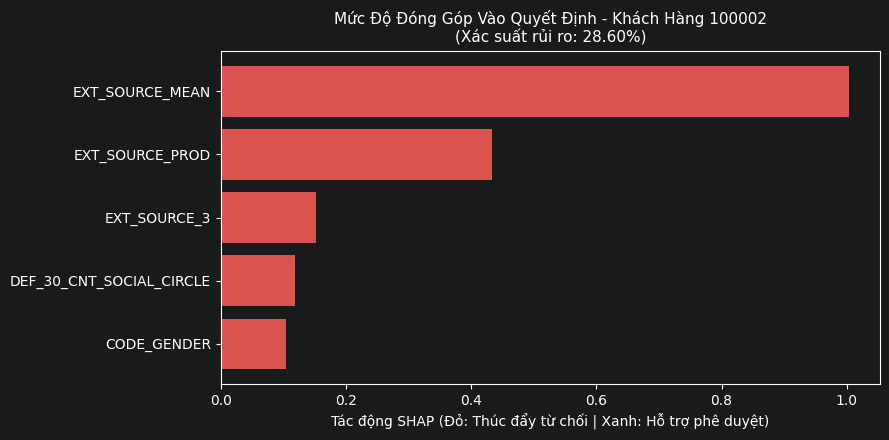


📋 PHIẾU ĐÁNH GIÁ VÀ GIẢI TRÌNH TÍN DỤNG | HỒ SƠ: 100003
🎯 Xác suất nợ xấu dự báo: 1.81% (Ngưỡng an toàn: 15.0%)
⚖️ ĐỀ XUẤT TỰ ĐỘNG: ✅ PHÊ DUYỆT CHO VAY (APPROVE)
----------------------------------------------------------------------
📌 TOP 5 YẾU TỐ QUYẾT ĐỊNH (REASON CODES CHO THẨM ĐỊNH VIÊN):
  1. [⚠️ Tăng rủi ro (Điểm trừ)] EXT_SOURCE_MEAN
     Giá trị ghi nhận: 0.46675654331836613 | Đóng góp điểm log-odds: +0.2246
  2. [🛡️ Giảm rủi ro (Điểm cộng)] ORGANIZATION_TYPE
     Giá trị ghi nhận: School | Đóng góp điểm log-odds: -0.2098
  3. [⚠️ Tăng rủi ro (Điểm trừ)] GOODS_CREDIT_DIFF
     Giá trị ghi nhận: -164002.5 | Đóng góp điểm log-odds: +0.1521
  4. [🛡️ Giảm rủi ro (Điểm cộng)] NAME_EDUCATION_TYPE
     Giá trị ghi nhận: Higher education | Đóng góp điểm log-odds: -0.1485
  5. [🛡️ Giảm rủi ro (Điểm cộng)] PREV_AMT_ANNUITY_MEAN
     Giá trị ghi nhận: 56553.99 | Đóng góp điểm log-odds: -0.0991


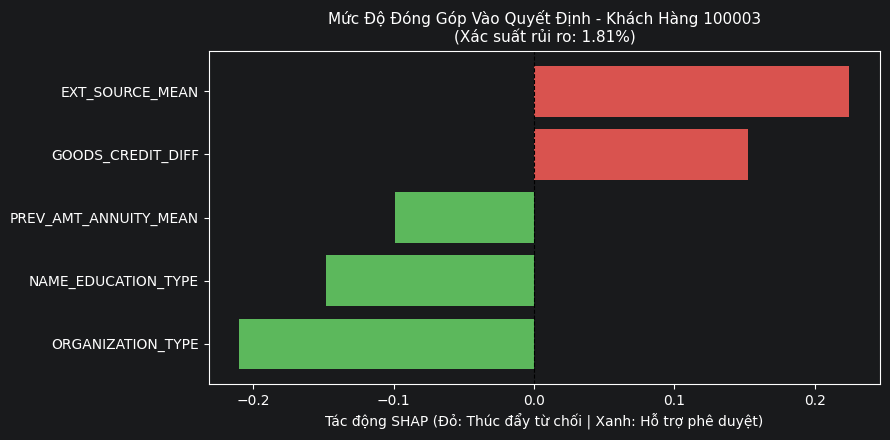

In [19]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. ĐỌC DỮ LIỆU
file_path = '/Users/nguyenminhtri/FinalYearPro/data/processed/master_train_dataset_v4_clean.parquet'
print(f"📂 Đang tải dữ liệu: {file_path}")
df = pd.read_parquet(file_path)

target_col = 'TARGET'
id_col = 'SK_ID_CURR' if 'SK_ID_CURR' in df.columns else None

ignore_cols = [target_col]
if id_col:
    ignore_cols.append(id_col)

X = df.drop(columns=[c for c in ignore_cols if c in df.columns])
y = df[target_col]

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype('category')

# 2. HUẤN LUYỆN MODEL CHAMPION TRÊN TOÀN BỘ DỮ LIỆU
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.021825282433423233,
    'num_leaves': 54,
    'max_depth': 7,
    'min_child_samples': 87,
    'colsample_bytree': 0.6047822116703159,
    'subsample': 0.8906002785722761,
    'subsample_freq': 1,
    'reg_alpha': 5.710785677539034,
    'reg_lambda': 0.0581442340641234,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

print("🚀 Đang huấn luyện mô hình Champion trên 100% dữ liệu (~1-2 phút)...")
model = lgb.LGBMClassifier(**lgb_params, n_estimators=1000)
model.fit(X, y)

# 3. KHỞI TẠO TREE-SHAP EXPLAINER
print("⚡ Khởi tạo TreeSHAP Explainer...")
explainer = shap.TreeExplainer(model)

# 4. HÀM XUẤT PHIẾU THẨM ĐỊNH CHO CHUYÊN VIÊN TÍN DỤNG
def generate_underwriter_report(customer_idx: int, threshold: float = 0.15):
    """
    customer_idx: Vị trí dòng của khách hàng trong tập dữ liệu X
    threshold: Ngưỡng rủi ro cắt (thường 0.10 - 0.20 trong tín dụng nợ xấu)
    """
    # Lấy thông tin khách hàng
    sample_x = X.iloc[[customer_idx]]
    prob = model.predict_proba(sample_x)[0, 1]
    client_id = df.iloc[customer_idx][id_col] if id_col else f"Index_{customer_idx}"

    # Tính toán SHAP value cho đúng 1 khách hàng này (chạy trong tích tắc < 0.1 giây)
    shap_res = explainer(sample_x)
    shap_vals = shap_res.values[0]
    base_val = shap_res.base_values[0]

    # Tạo bảng giải trình chi tiết từng yếu tố
    feature_names = X.columns
    df_shap = pd.DataFrame({
        'Feature': feature_names,
        'Value': sample_x.values[0],
        'SHAP_Impact': shap_vals
    })

    # Sắp xếp theo mức độ tác động mạnh nhất
    df_shap['Abs_Impact'] = df_shap['SHAP_Impact'].abs()
    top_factors = df_shap.sort_values(by='Abs_Impact', ascending=False).head(5).copy()

    # Gán nhãn nghiệp vụ tài chính
    top_factors['Impact_Type'] = top_factors['SHAP_Impact'].apply(
        lambda v: '⚠️ Tăng rủi ro (Điểm trừ)' if v > 0 else '🛡️ Giảm rủi ro (Điểm cộng)'
    )

    decision = "❌ TỪ CHỐI CHO VAY (DECLINE)" if prob >= threshold else "✅ PHÊ DUYỆT CHO VAY (APPROVE)"

    # IN PHIẾU THẨM ĐỊNH (TEXT SLIP)
    print("\n" + "=" * 70)
    print(f"📋 PHIẾU ĐÁNH GIÁ VÀ GIẢI TRÌNH TÍN DỤNG | HỒ SƠ: {client_id}")
    print("=" * 70)
    print(f"🎯 Xác suất nợ xấu dự báo: {prob * 100:.2f}% (Ngưỡng an toàn: {threshold * 100:.1f}%)")
    print(f"⚖️ ĐỀ XUẤT TỰ ĐỘNG: {decision}")
    print("-" * 70)
    print("📌 TOP 5 YẾU TỐ QUYẾT ĐỊNH (REASON CODES CHO THẨM ĐỊNH VIÊN):")

    for rank, (_, row) in enumerate(top_factors.iterrows(), 1):
        print(f"  {rank}. [{row['Impact_Type']}] {row['Feature']}")
        print(f"     Giá trị ghi nhận: {row['Value']} | Đóng góp điểm log-odds: {row['SHAP_Impact']:+.4f}")
    print("=" * 70)

    # VẼ BIỂU ĐỒ TRỰC QUAN CHO HỒ SƠ
    plt.figure(figsize=(9, 4.5))
    top_factors_sorted = top_factors.sort_values(by='SHAP_Impact', ascending=True)
    colors = ['#d9534f' if v > 0 else '#5cb85c' for v in top_factors_sorted['SHAP_Impact']]

    plt.barh(top_factors_sorted['Feature'], top_factors_sorted['SHAP_Impact'], color=colors)
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    plt.title(f"Mức Độ Đóng Góp Vào Quyết Định - Khách Hàng {client_id}\n(Xác suất rủi ro: {prob*100:.2f}%)", fontsize=11)
    plt.xlabel("Tác động SHAP (Đỏ: Thúc đẩy từ chối | Xanh: Hỗ trợ phê duyệt)")
    plt.tight_layout()
    plt.show()

# =====================================================================
# THỬ NGHIỆM TRÊN 2 KỊCH BẢN THẨM ĐỊNH THỰC TẾ
# =====================================================================
# Tìm 1 khách hàng có rủi ro cao nhất (Target = 1) và 1 khách hàng uy tín (Target = 0)
high_risk_idx = np.where(y == 1)[0][0]
low_risk_idx = np.where(y == 0)[0][0]

# 1. Thẩm định ca hồ sơ bị từ chối
generate_underwriter_report(customer_idx=high_risk_idx, threshold=0.15)

# 2. Thẩm định ca hồ sơ được duyệt
generate_underwriter_report(customer_idx=low_risk_idx, threshold=0.15)